# Evaluating the AIx Distribution in the Dataframe

This notebook will evaluate the AIx distribution in the dataframe to assess the prediction range that we can expect in the ML model. 

In [14]:
# imports
import os
import sys

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

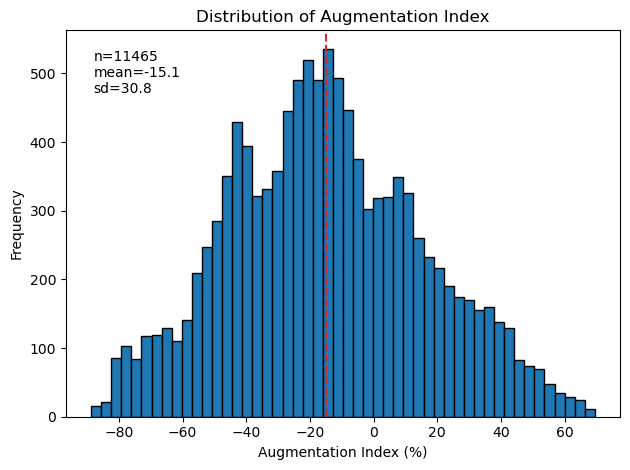

In [16]:
# load the data
df = pd.read_pickle('../data/wvfIndexData.pkl')

# calculate augmentation index
df['aix'] = df.apply(lambda x: 100*(x['wvf'][x['p2_ind']] - x['wvf'][x['p1_ind']]) / x['wvf'].ptp(), axis=1)

# plot the distribution of augmentation index
fig, ax = plt.subplots()
df['aix'].hist(ax=ax, bins=50, grid=False, color='tab:blue', edgecolor='black')
ax.axvline(df['aix'].mean(), color='tab:red', linestyle='--')
ax.set_xlabel('Augmentation Index (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Augmentation Index')
ax.text(0.05, 0.95, 'n={}\nmean={:.1f}\nsd={:.1f}'.format(len(df), df['aix'].mean(), df['aix'].std()), transform=ax.transAxes, verticalalignment='top')
plt.tight_layout()
plt.show()